# KNN
- Liad Mandil, 315096073
- Maxim Prokopchuk, 337875397

## Imports

In [97]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier as KNN
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

-------------------------------------


## Load Data

In [98]:
spaceship_data = pd.read_csv('final_data.csv')

## split to x and y

In [99]:
y = spaceship_data["Transported"].astype(int)
x = spaceship_data.drop(columns=["Transported", "GroupId"])

In [100]:
knn_pipe = Pipeline([
    ("knn", KNN())
])

## Train-Test Split

In [101]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

In [102]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

------------------

## KNN Model

In [103]:
param_grid = {
    "knn__n_neighbors": list(range(1, 40, 2)),
    "knn__weights": ["uniform", "distance"],
    "knn__metric": ["euclidean", "manhattan"]
}

grid = GridSearchCV(
    knn_pipe,
    param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(x_train, y_train)
best_model = grid.best_estimator_

## results

In [104]:
best_model = grid.best_estimator_

In [105]:
y_pred_train  = best_model.predict(x_train)

In [106]:
train_acc = accuracy_score(y_train, y_pred_train)

אחוז דיוק על test

In [107]:
print("="*40)
print("BEST KNN — TRAIN SET PERFORMANCE")
print("="*40)
print(f"Accuracy : {train_acc*100:.2f}%")
print("="*40)

BEST KNN — TRAIN SET PERFORMANCE
Accuracy : 79.60%


טבלה שמציגה את הטבלה להצגת 5 המודלים הכי טובים שנלמדו

In [108]:
results = pd.DataFrame(grid.cv_results_)

summary = results[
    [
        "param_knn__n_neighbors",
        "param_knn__weights",
        "param_knn__metric",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
].sort_values("rank_test_score")

summary.head(5)

,param_knn__n_neighbors,param_knn__weights,param_knn__metric,mean_test_score,std_test_score,rank_test_score
26,27,uniform,euclidean,0.788231,0.013537,1
76,37,uniform,manhattan,0.787500,0.013157,2
74,35,uniform,manhattan,0.787500,0.013362,3
68,29,uniform,manhattan,0.786916,0.013398,4
28,29,uniform,euclidean,0.786770,0.012731,5


גרף שמראה את אחוז הדיוק של המודל הטוב ביותר לשאר המודלים

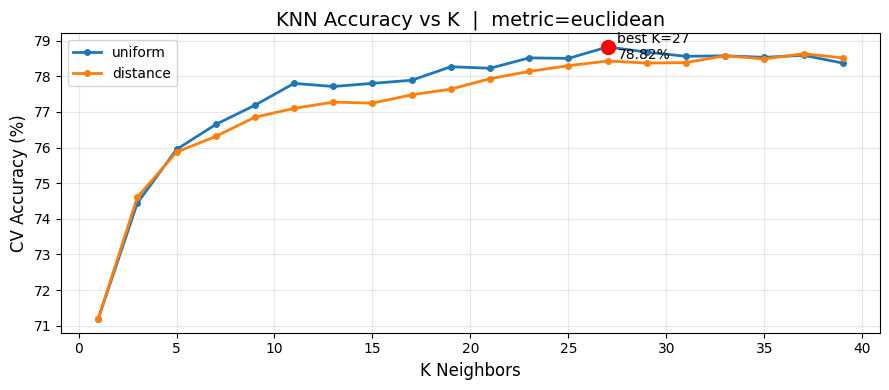

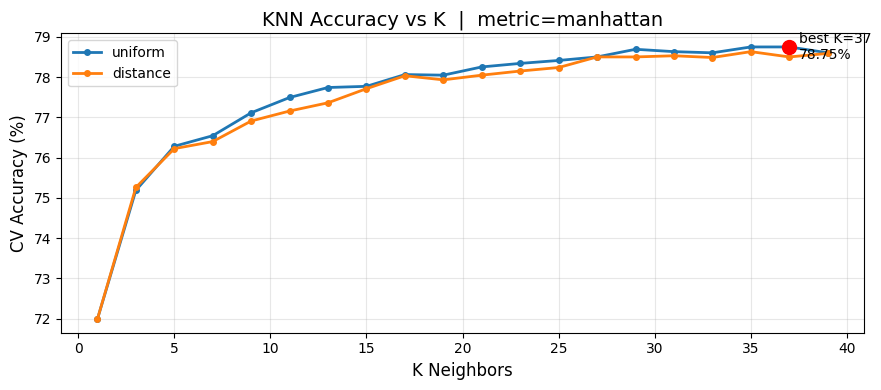

In [109]:
results = pd.DataFrame(grid.cv_results_)

summary = results[[
    "param_knn__n_neighbors",
    "param_knn__weights",
    "param_knn__metric",
    "mean_test_score",
    "std_test_score"
]].copy()

summary["K"] = summary["param_knn__n_neighbors"].astype(int)
summary["weights"] = summary["param_knn__weights"].astype(str)
summary["metric"] = summary["param_knn__metric"].astype(str)

for metric in sorted(summary["metric"].unique()):
    sub = summary[summary["metric"] == metric].sort_values("K")

    plt.figure(figsize=(9, 4))

    for w in ["uniform", "distance"]:
        curve = sub[sub["weights"] == w].sort_values("K")
        plt.plot(
            curve["K"],
            curve["mean_test_score"] * 100,
            marker="o",
            linestyle="-",
            linewidth=2,
            markersize=4,
            label=w
        )

    # best נקודה אדומה (הכי גבוה מתוך שתי העקומות)
    best_row = sub.loc[sub["mean_test_score"].idxmax()]
    best_k = int(best_row["K"])
    best_acc = float(best_row["mean_test_score"] * 100)

    plt.scatter(best_k, best_acc, color="red", s=100, zorder=5)
    plt.text(best_k + 0.5, best_acc, f"best K={best_k}\n{best_acc:.2f}%", va="center")

    plt.xlabel("K Neighbors", fontsize=12)
    plt.ylabel("CV Accuracy (%)", fontsize=12)
    plt.title(f"KNN Accuracy vs K  |  metric={metric}", fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


חישוב Precision, Recall, F1 מתוך ה-CM

In [110]:
cm_train = confusion_matrix(y_train, y_pred_train)

TN, FP, FN, TP = cm_train.ravel()

precision = TP / (TP + FP)
recall    = TP / (TP + FN)
f1        = 2 * (precision * recall) / (precision + recall)

print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1 Score:  {f1:.3f}")

Precision: 0.771
Recall:    0.845
F1 Score:  0.807


מטריצת ערבול למודל המוצלח ביותר TRAIN

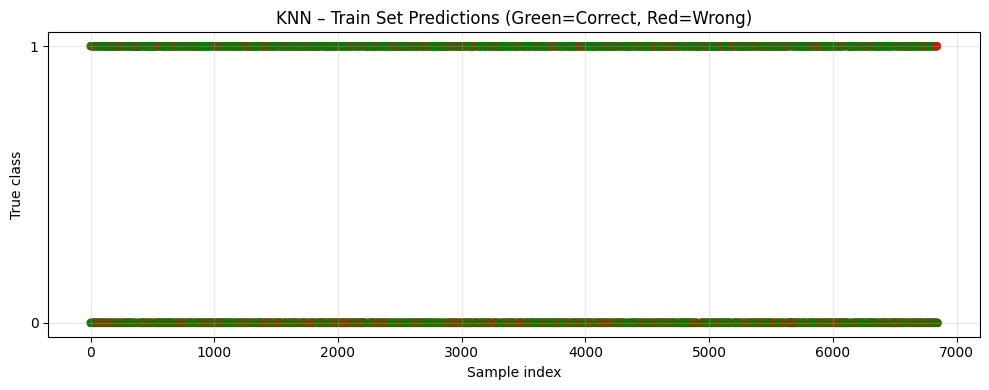

KNN Train Accuracy: 79.60%
Errors: 1397 / 6847


In [111]:
correct = (y_pred_train == y_train)

# צבעים: ירוק = נכון, אדום = שגוי
colors = np.where(correct, "green", "red")

plt.figure(figsize=(10,4))
plt.scatter(range(len(y_train)), y_train, c=colors, s=25, alpha=0.7)

plt.yticks([0,1])
plt.xlabel("Sample index")
plt.ylabel("True class")
plt.title("KNN – Train Set Predictions (Green=Correct, Red=Wrong)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"KNN Train Accuracy: {100*train_acc:.2f}%")
print(f"Errors: {np.sum(~correct)} / {len(correct)}")

<Figure size 600x600 with 0 Axes>

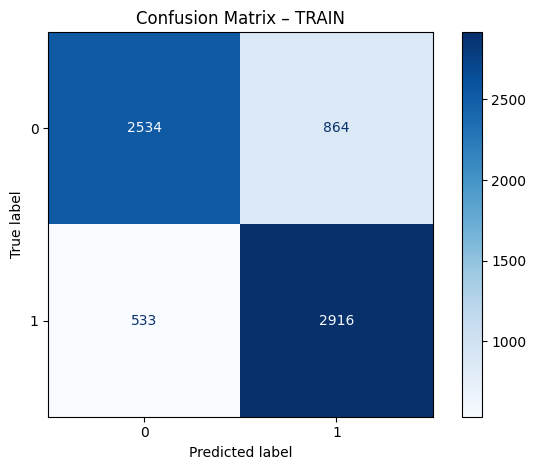

In [112]:

disp_train = ConfusionMatrixDisplay(
    confusion_matrix=cm_train
)

plt.figure(figsize=(6,6))
disp_train.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix – TRAIN")
plt.tight_layout()
plt.show()